**import libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Loadind Dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


In [16]:
# Load dataset
df = pd.read_csv("Advertising.csv")

print(df.head())

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [15]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
       Unnamed: 0          TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400

In [14]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64


In [6]:
df.duplicated().sum()

np.int64(0)

Split the Dataset into Training and Testing Sets

In [8]:
# Independent Variable (Advertising through TV)
X = df[['TV']]

# Dependent Variable (Sales)
y = df['sales']

Split the Dataset into Training and Testing Sets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (160, 1)
Testing Data : (40, 1)


Train the Model

In [10]:
# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display coefficient and intercept
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 0.046529733705443346
Intercept: 7.119638430592953


Make Predictions

In [11]:
# Predict Sales
y_pred = model.predict(X_test)

# Compare Actual vs Predicted
result = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

print(result.head(10))

     Actual Sales  Predicted Sales
95           16.9        14.717944
15           22.4        16.211548
30           21.4        20.748197
158           7.3         7.664036
128          24.7        17.370139
115          12.6        10.614021
69           22.3        17.207285
170           8.4         9.446125
174          11.5        17.467851
45           14.9        15.266995


Evaluate the Model

In [12]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 2.444420003751042
Mean Squared Error (MSE): 10.204654118800956
Root Mean Squared Error (RMSE): 3.194472431998898
R2 Score: 0.6766954295627076


Visualize the Regression Line

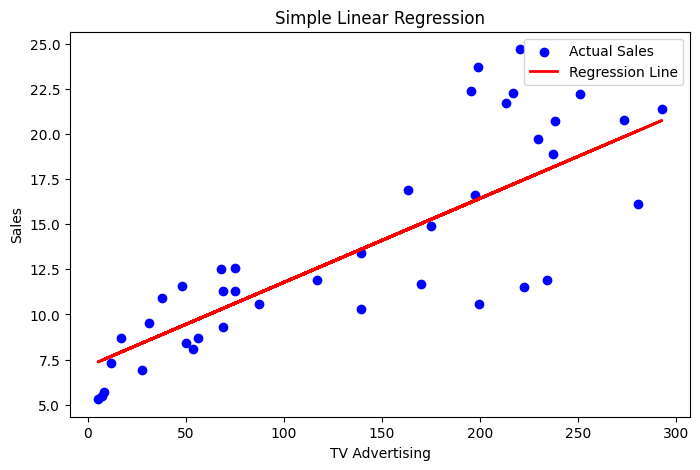

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, color='blue', label='Actual Sales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.title("Simple Linear Regression")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.legend()

plt.show()

# Conclusion:

The Simple Linear Regression model predicts product sales using TV advertising expenditure. The regression line demonstrates a positive linear relationship, and the R² score indicates how well TV advertising explains the variation in sales.